<a href="https://colab.research.google.com/github/LaimengEung/inf-604-data-analysis-i-repo/blob/master/Copy_of_Lab7_Linear_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TP7 - Linear & Logistic Regression**

**Course**: **INF-604: Data Analysis** <br>
**Lecturer**: **Sothea HAS, PhD**

-----

**Objective:** In this lab, you will reproduce the result we have done in linear and logistic regression. Moreover, you will explore beyond what we have done including using multiple inputs variables, compare their performances and feature engineering to further elevate the model performance.

- You can work directly with `Google Colab` here: [Lab7_Linear_Logistic_Regression.ipynb](https://colab.research.google.com/drive/1zwoEzZpEEVX5yYgUh3Pbd5P73L0v_0Xv?usp=sharing).


-----


# **I. Linear Regression**

We are working with kaggle [`Auto-MPG`](https://www.kaggle.com/datasets/uciml/autompg-dataset) dataset. Now, find a way to import the dataset into our environment.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/autompg-dataset")

# import the data into the environment but I don't know its name!
import pandas as pd
data = pd.read_csv(path + '/auto-mpg.csv') # path to the data + the data name
data.head(5)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


## **1. Data Preprocessing and EDA**

**A. Univariate Analysis**:

- Check and modify columns with wrong data type.
- What's wrong with column `horsepower`? How would you solve this problem?
- Make sure all the columns are in correct data type as shown in [slide 7](https://hassothea.github.io/Data_Analysis_AUPP/Slides/Linear_Regression.html#/eda).
- Compute descriptive statistics of the data and visualize their distribution as illustrated in [slide 8 and 9](https://hassothea.github.io/Data_Analysis_AUPP/Slides/Linear_Regression.html#/eda-1).

In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


> horsepower is an object, not numeric dtype

In [3]:
data['horsepower'] = data['horsepower'].astype('float')
# ValueError: could not convert string to float: '?'

ValueError: could not convert string to float: '?'

In [4]:
hp_numeric = pd.to_numeric(data['horsepower'], errors='coerce') # forces errors into NaN
data[hp_numeric.isna()]         # queries for the missing values in hp_numeric (it's currently a data['horsepower'])

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
32,25.0,4,98.0,?,2046,19.0,71,1,ford pinto
126,21.0,6,200.0,?,2875,17.0,74,1,ford maverick
330,40.9,4,85.0,?,1835,17.3,80,2,renault lecar deluxe
336,23.6,4,140.0,?,2905,14.3,80,1,ford mustang cobra
354,34.5,4,100.0,?,2320,15.8,81,2,renault 18i
374,23.0,4,151.0,?,3035,20.5,82,1,amc concord dl


In [5]:
# drop the ? in horsepower
data['horsepower'] = hp_numeric
data = data.dropna()

In [6]:
# orrrr, simpler:
data = data.query("horsepower != '?'")

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model year    392 non-null    int64  
 7   origin        392 non-null    int64  
 8   car name      392 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 30.6+ KB


In [8]:
data['origin'] = data['origin'].astype('category')

In [9]:
quan_cols = data.select_dtypes(include='number').columns.to_list()
qual_cols = data.select_dtypes(exclude='number').columns.to_list()
qual_cols.remove('car name')

print("Quantitative Columns:", quan_cols)
print("Qualitative Columns:", qual_cols)


Quantitative Columns: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year']
Qualitative Columns: ['origin']


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

<Axes: xlabel='origin', ylabel='count'>

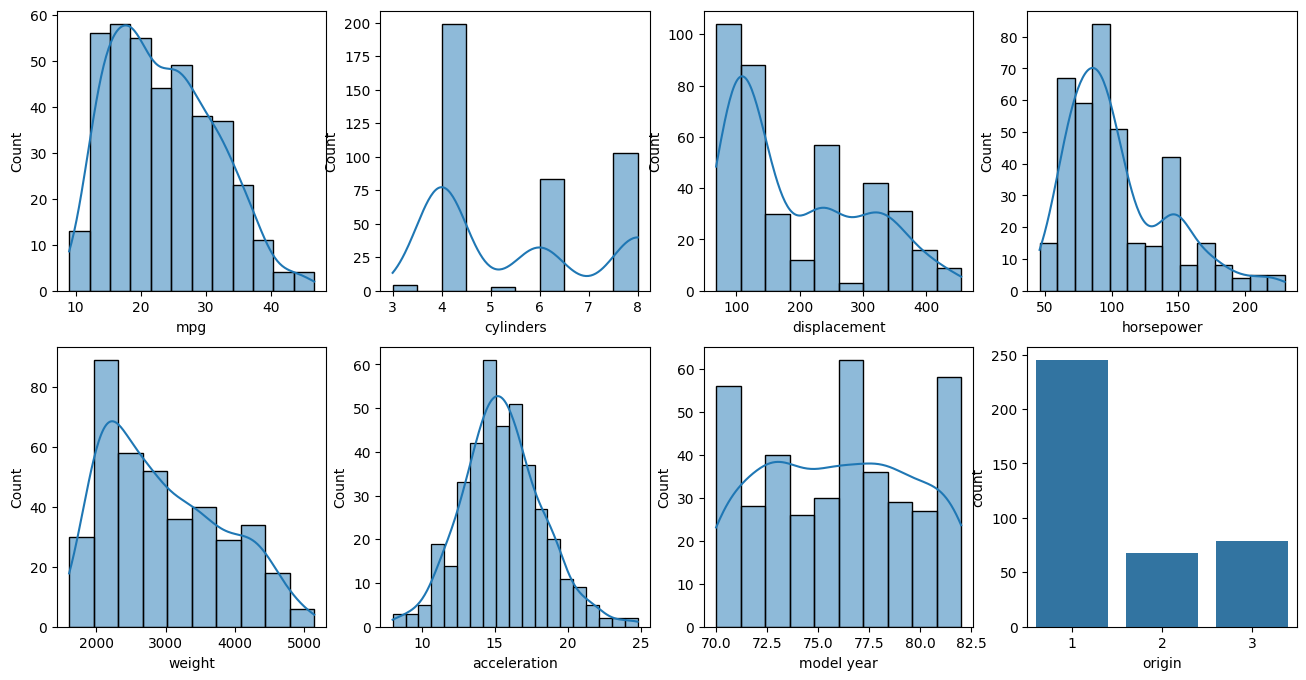

In [11]:
fig, ax = plt.subplots(2, 4, figsize=(16,8))

for i, var in enumerate(quan_cols):
    row = i // 4
    col = i % 4
    sns.histplot(data, x=var, ax=ax[row, col], kde=True)

sns.countplot(data, x='origin', ax=ax[1, 3])

In [12]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
mpg,392.0,23.445918,7.805007,9.0,17.000,22.75,29.000,46.6
cylinders,392.0,5.471939,1.705783,3.0,4.000,4.00,8.000,8.0
displacement,392.0,194.411990,104.644004,68.0,105.000,151.00,275.750,455.0
horsepower,392.0,104.469388,38.491160,46.0,75.000,93.50,126.000,230.0
weight,392.0,2977.584184,849.402560,1613.0,2225.250,2803.50,3614.750,5140.0
acceleration,392.0,15.541327,2.758864,8.0,13.775,15.50,17.025,24.8
model year,392.0,75.979592,3.683737,70.0,73.000,76.00,79.000,82.0


**B. Bivariate Analysis:**

- Compute correlation matrix and pairplot (see [slide 10](https://hassothea.github.io/Data_Analysis_AUPP/Slides/Linear_Regression.html#/section)).
- Also reproduce conditional boxplot of influence of `origin` on `mpg` as illustrated in [slide 11](https://hassothea.github.io/Data_Analysis_AUPP/Slides/Linear_Regression.html#/section-1).

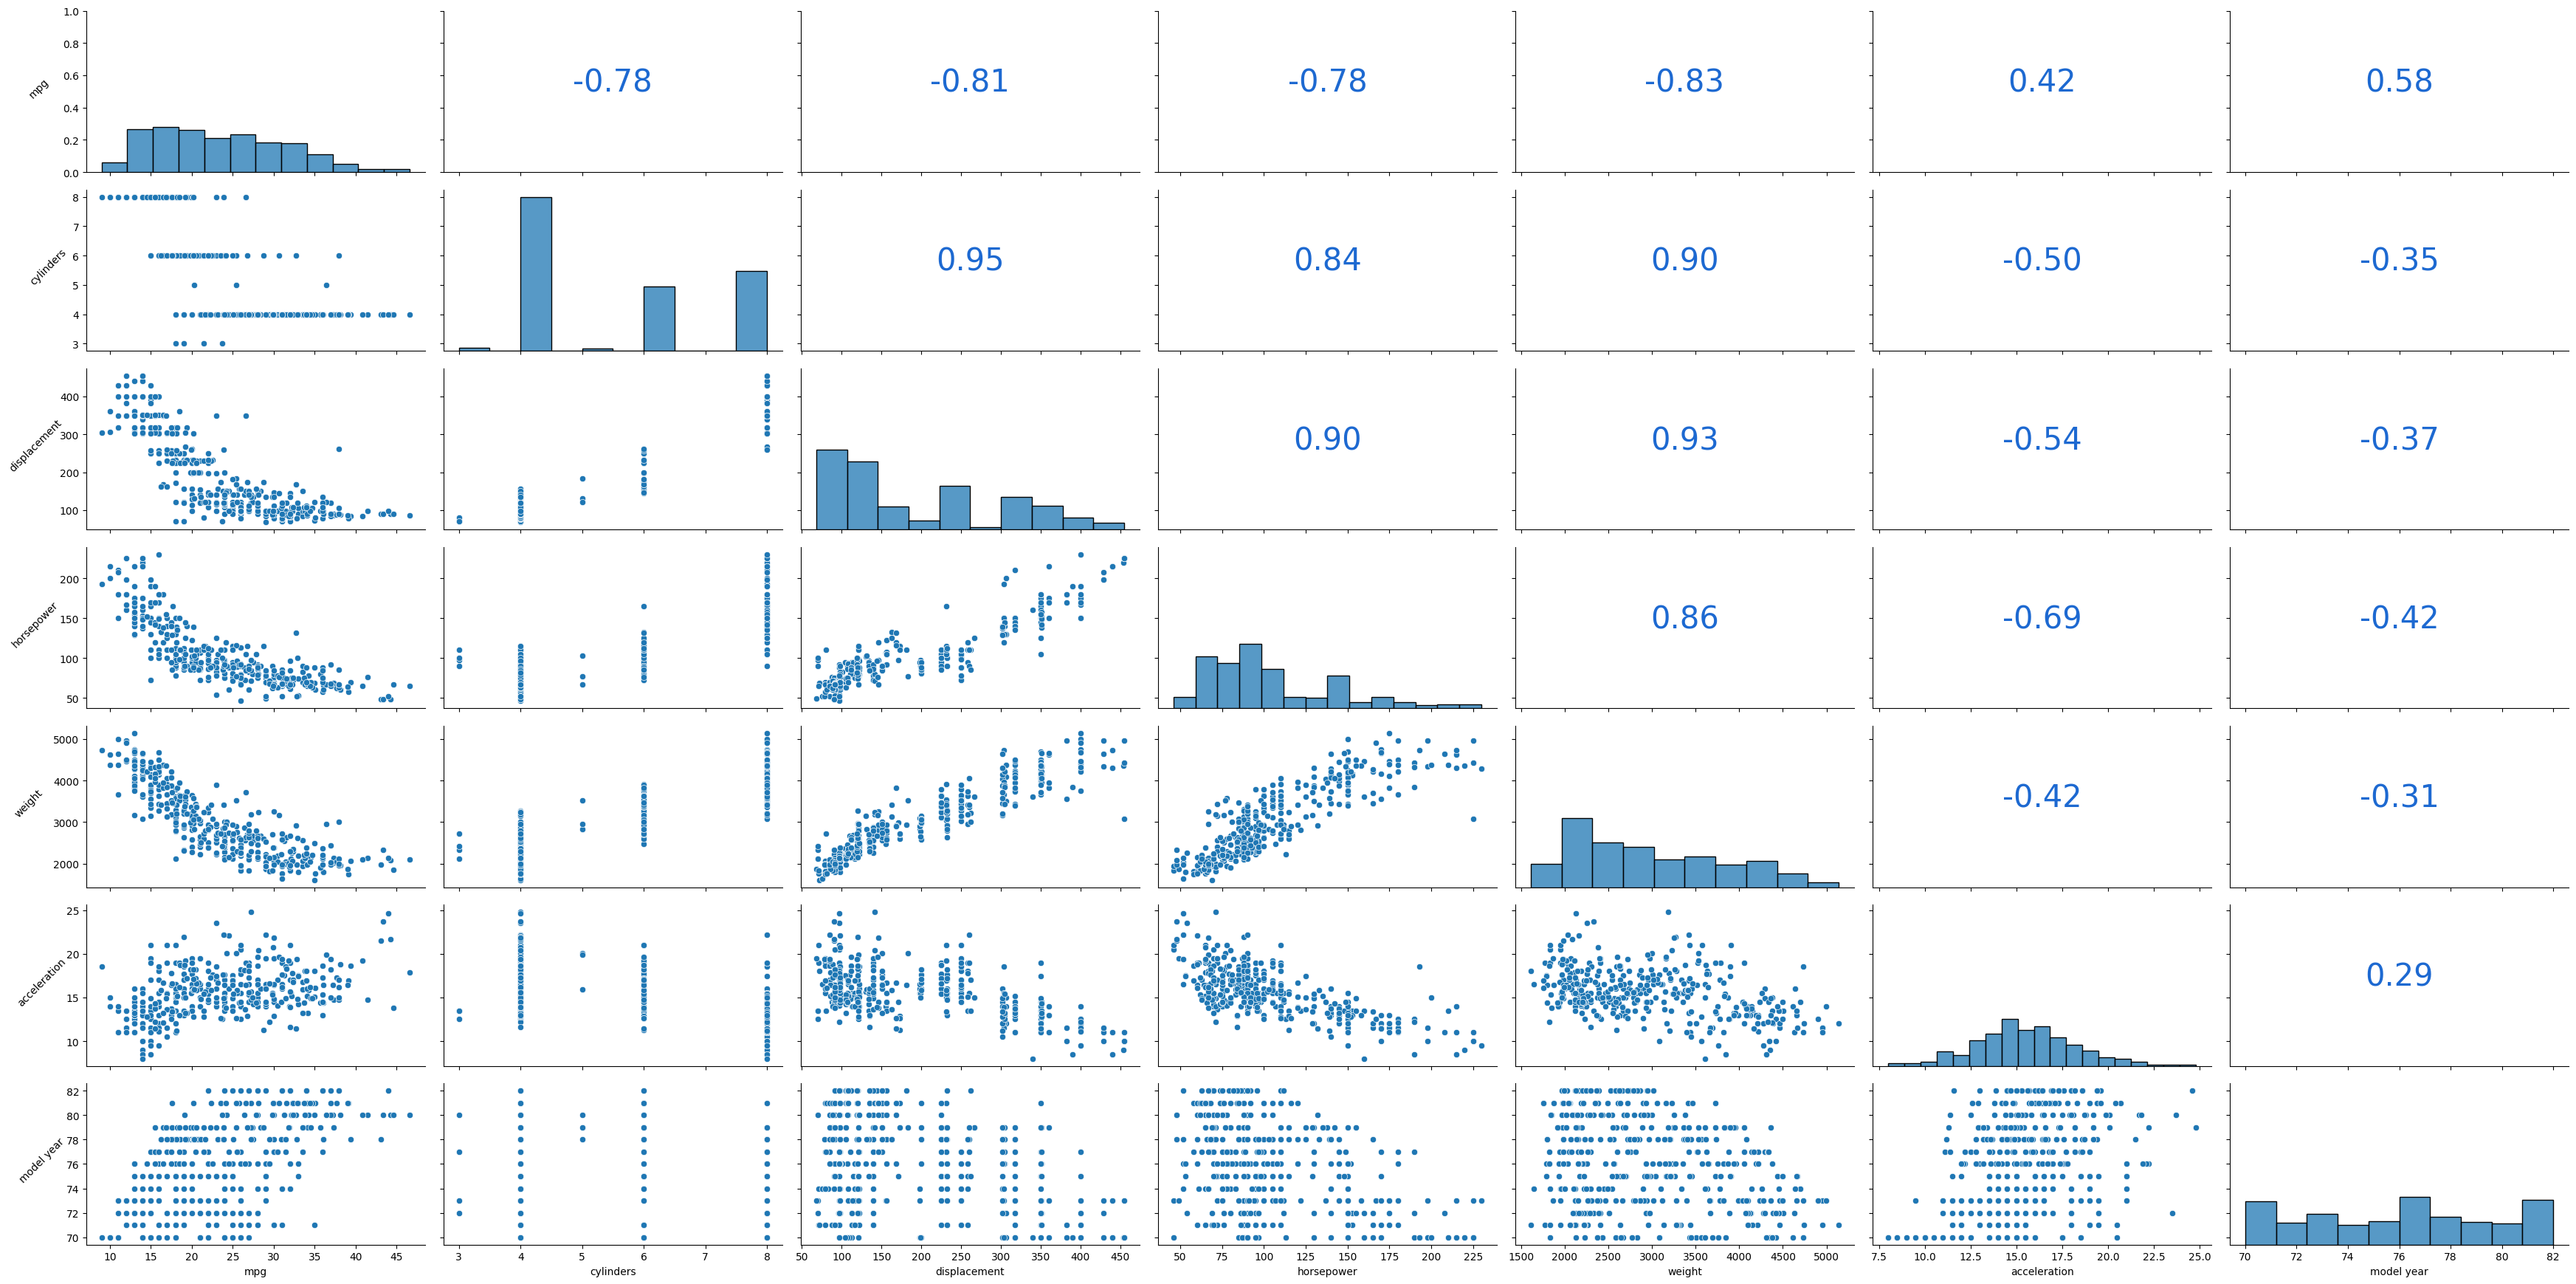

In [13]:
# Correlation matrix and pairplot
pair_grid = sns.PairGrid(data=data[quan_cols], aspect=2)

# # Map plots to the lower triangle only
pair_grid.map_lower(sns.scatterplot)    # Scatterplots in the lower triangle
pair_grid.map_diag(sns.histplot)        # Histograms on the diagonal

# pair_plot = sns.pairplot(data=data[quan_cols], aspect=2.5)
def corr_func(x, y, **kws):
    r1 = np.corrcoef(x, y)[0, 1]    # takes the second element of first array
    plt.gca().annotate(f"{r1:.2f}", xy=(0.5, 0.5),      # Get Current Axes: do manipulation to current axes
                       xycoords='axes fraction',
                       ha='center', fontsize=30, color='#1d69d1')
    return r1

pair_grid.map_upper(corr_func)
for ax in pair_grid.axes[:, 0]:
# for ax in pair_grid.axes.flatten():
    ax.set_ylabel(ax.get_ylabel(), rotation=45, labelpad=20)
plt.tight_layout()
plt.show()

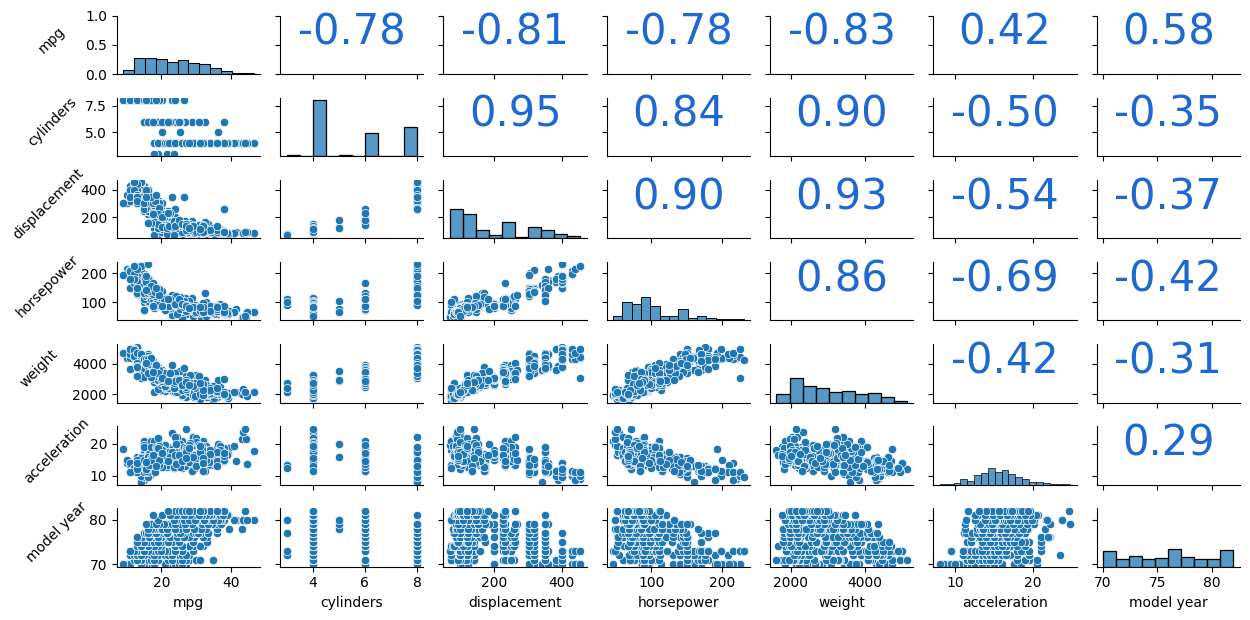

In [14]:
pair_grid = sns.PairGrid(data=data[quan_cols], height=0.9, aspect=2)

# Map plots to the lower triangle only
pair_grid.map_lower(sns.scatterplot)  # Scatterplots in the lower triangle
pair_grid.map_diag(sns.histplot)      # Histograms on the diagonal

# pair_plot = sns.pairplot(data=data[quan_vars], height=0.9, aspect=2.5)
def corr_func(x, y, **kws): 
    r1 = np.corrcoef(x, y)[0, 1]
    plt.gca().annotate(f"{r1:.2f}", xy=(0.5, 0.5), 
                       xycoords='axes fraction', 
                       ha='center', fontsize=30, color='#1d69d1')

pair_grid.map_upper(corr_func)
for ax in pair_grid.axes[:, 0]:  # Access the first column of axes (y-axis labels)
    ax.set_ylabel(ax.get_ylabel(), rotation=45, labelpad=20)
plt.tight_layout()
plt.show()

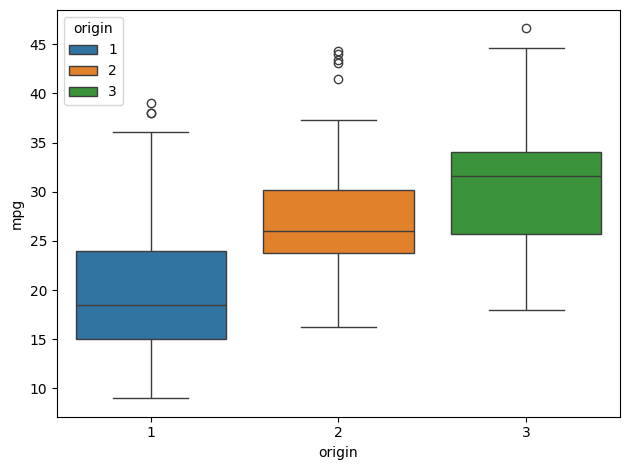

In [17]:
sns.boxplot(data=data, x="origin", y="mpg", hue="origin")
plt.tight_layout()
plt.show()

## **2. Simple Linear Regression (SLR)**

- Pick one input (except `weight`) and build linear regression model to predict `mpg`.
- Draw scatterplot of that input vs `mpg`. Add the fitted line to the existing scatterplot.
- Compute $R^2$ and check the residual of the model. Explain the result.
- Check if the coefficient of your model is significantly different from 0 within 95% certainty.
- Interpret the model.

find the obvious non-linear feature (the one that grows the most from pearson to Spearman)

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_percentage_error

In [20]:
# Let's choose displacement for Linear Regression

X = data[['displacement']]      # 1 feature : displacement
y = data['mpg']                 # target    : mpg

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

slr_model = LinearRegression()

slr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
coefficient = slr_model.coef_[0]
intercept = slr_model.intercept_

print(f"y = {coefficient:.2f}x + {intercept:.2f}")

y = -0.06x + 35.77


In [23]:
# Predictions
y_pred = slr_model.predict(X_test)

<Axes: xlabel='displacement', ylabel='mpg'>

<Axes: xlabel='displacement', ylabel='mpg'>

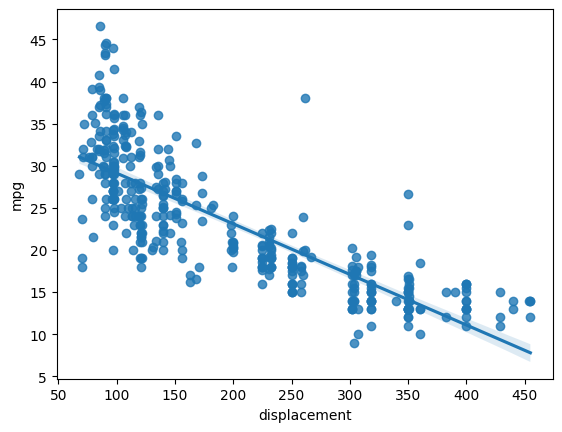

In [29]:
# lmplot (linear model) is like the advanced version of regplot 
    # it allows more visualizing customization
    # However, using hue will create multiple lines for each of the hue
    # regplot, on the other hand, will works best if you want just one linear line 

sns.regplot(data, x='displacement', y='mpg')
# sns.lmplot(data, x='displacement', y='mpg', hue='origin')

0.7933789972298892


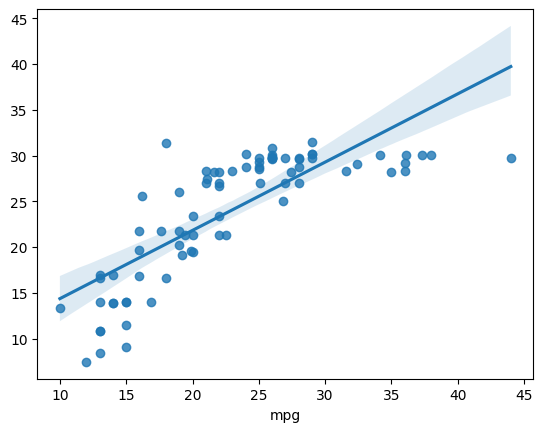

In [35]:
sns.regplot(x=y_test, y=y_pred)

print(np.corrcoef(y_test, y_pred)[0, 1])

In [41]:
mae = mean_absolute_error(y_test, y_pred)
mse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")

Mean Absolute Error: 3.69
Mean Squared Error: 4.61
R2 Score: 0.58


On average, the model miss about 21% of the predictions? (the MAPE: Mean Absolute Percentage Error)
Let's add this alongside RMSE (my mistake is about RMSE% off) if prediction is 1000, RMSE of 20 will be off, and we know that actual value is around 800 - 1200

In [43]:
df_perf = pd.DataFrame(
    {
        'R2' : [r2_score(y_test, y_pred)],
        'RMSE/MEAN' : [root_mean_squared_error(y_test, y_pred)/y_test.mean()],
        'MAPE' : [mean_absolute_percentage_error(y_test, y_pred)],
    }, index = ['SLR']
)
df_perf

,R2,RMSE/MEAN,MAPE
SLR,0.584106,0.20174,0.17025


## **3. Multiple Linear Regression (MLR)**

**A. All at once:**

- Build multiple linear regression using all inputs.
- Compute $R^2$ and $R^2_{\text{adj}}$ and explain the result.
- Check the residual. Explain the result.
- Are all inputs significantly related with the target `mpg`?


In [46]:
# One-hot Encode origin column first
data_encoded = pd.get_dummies(data, columns=['origin'], drop_first=True, dtype='int')
data_encoded.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,car name,origin_2,origin_3
0,18.0,8,307.0,130.0,3504,12.0,70,chevrolet chevelle malibu,0,0
1,15.0,8,350.0,165.0,3693,11.5,70,buick skylark 320,0,0
2,18.0,8,318.0,150.0,3436,11.0,70,plymouth satellite,0,0
3,16.0,8,304.0,150.0,3433,12.0,70,amc rebel sst,0,0
4,17.0,8,302.0,140.0,3449,10.5,70,ford torino,0,0


In [56]:
X1 = data_encoded.drop(columns=['mpg', 'car name'])
y1 = data_encoded['mpg']

X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42)

mlr_model = LinearRegression()

mlr_model.fit(X_train1, y_train1)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [57]:
coef_df = pd.DataFrame({
    'Feature': X1.columns,
    'Coefficient': mlr_model.coef_
})

print(coef_df)
print(f"\nIntercept: {mlr_model.intercept_:.2f}")

        Feature  Coefficient
0     cylinders    -0.342101
1  displacement     0.019206
2    horsepower    -0.021620
3        weight    -0.006423
4  acceleration     0.042198
5    model year     0.797161
6      origin_2     2.875499
7      origin_3     3.205969

Intercept: -19.33


<Axes: xlabel='mpg'>

<Axes: xlabel='mpg'>

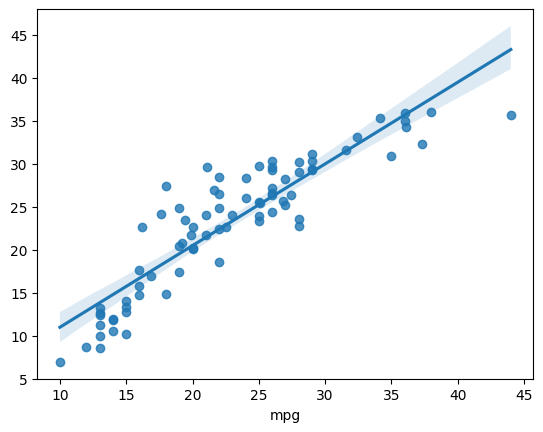

In [58]:
y_pred1 = mlr_model.predict(X_test1)

sns.regplot(x=y_test1, y=y_pred1)

In [59]:
df_perf = pd.concat([df_perf, pd.DataFrame(
    {
        'R2' : [r2_score(y_test1, y_pred1)],
        'RMSE/MEAN' : [root_mean_squared_error(y_test1, y_pred1)/y_test1.mean()],
        'MAPE' : [mean_absolute_percentage_error(y_test1, y_pred1)],
    }, index = ['MLR'])])
df_perf

,R2,RMSE/MEAN,MAPE
SLR,0.584106,0.201740,0.170250
MLR,0.792277,0.142575,0.120395


In [61]:
n = len(y_test1)          # number of samples
p = X_test1.shape[1]      # number of features
r2_mlr = r2_score(y_test1, y_pred1)
r2_adj_mlr = 1 - (1 - r2_mlr) * (n - 1) / (n - p - 1)

print(f"R2 Score: {r2_mlr:.4f}")
print(f"R2 Adjusted: {r2_adj_mlr:.4f}")

R2 Score: 0.7923
R2 Adjusted: 0.7685


The difference between Adjusted and actual R2 of MLR model is **very small** (~0.02).

This means that the features are mostly useful and contributing to the predictions. And, our model is performing well, with more features.

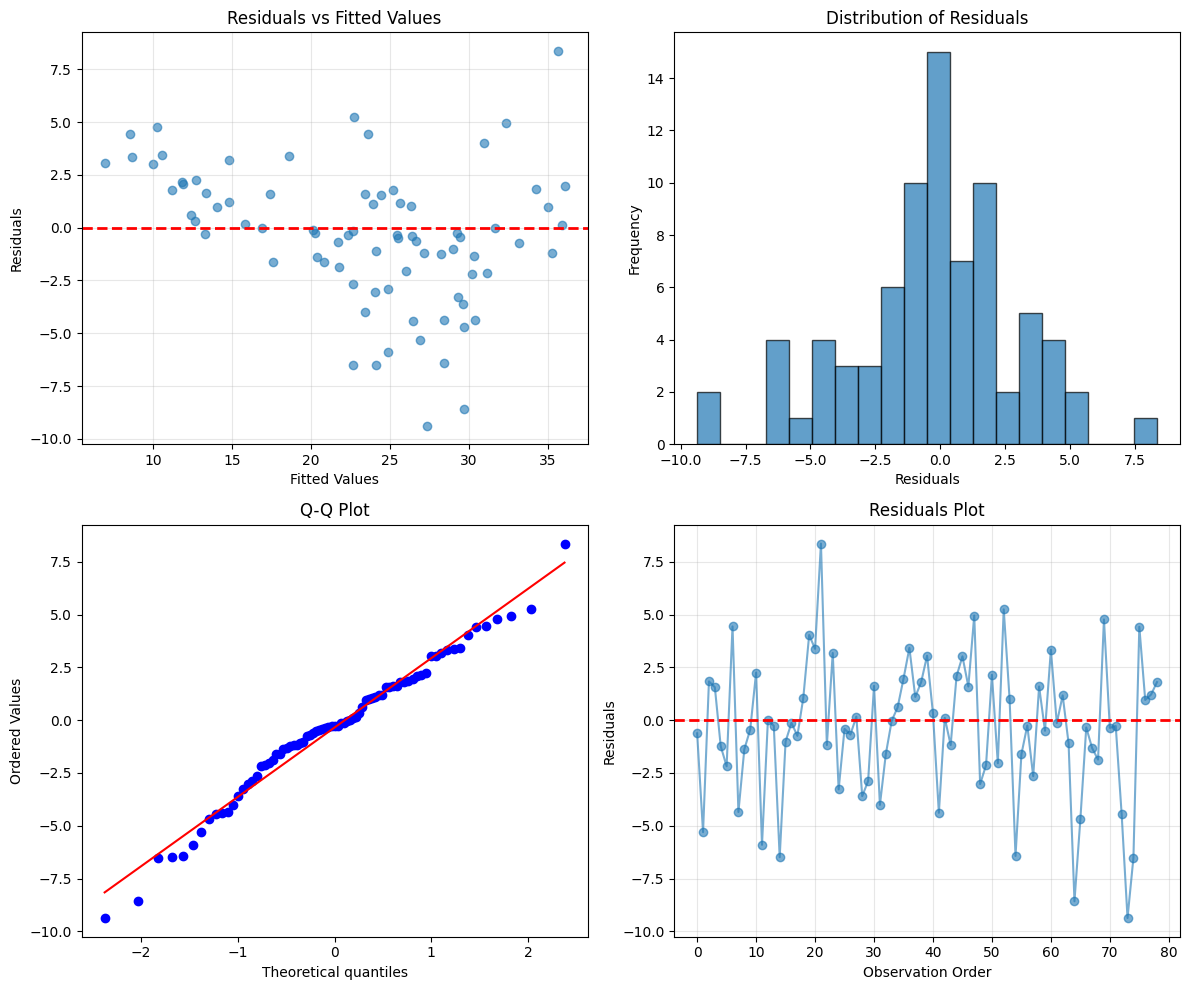

Mean of Residuals: -0.347685 (should be ~0)
Std Dev of Residuals: 3.2375
Min Residual: -9.3670
Max Residual: 8.3611


In [63]:
# Calculate residuals
residuals = y_test1 - y_pred1  # Use test data to answer whether our model meet linear regression assumption.

# Create diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Residuals vs Fitted Values (check homoscedasticity)
axes[0, 0].scatter(y_pred1, residuals, alpha=0.6)
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted Values')
axes[0, 0].grid(True, alpha=0.3)

# 2. Histogram of Residuals (check normality)
axes[0, 1].hist(residuals, bins=20, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Residuals')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Residuals')

# 3. Q-Q Plot (check normality)
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot')

# 4. Residuals over order (check independence)
axes[1, 1].plot(residuals.values, 'o-', alpha=0.6)
axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Observation Order')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('Residuals Plot')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Mean of Residuals: {np.mean(residuals):.6f} (should be ~0)")
print(f"Std Dev of Residuals: {np.std(residuals):.4f}")
print(f"Min Residual: {np.min(residuals):.4f}")
print(f"Max Residual: {np.max(residuals):.4f}")

- Scatterplot: There seems to be random scatter around the red line
- Histogram: It is normally-distributed
- Q-Q Plot (Check if data is normally distributed): the points is very closely to the diagonal line
- Residuals over order (mostly used for timeseries pattern; to check for autocorrelation): since there are random scatter, there seems to be no autocorrelation (it indicates independent errors, no trends).

Overall, the MLR model is pretty good. The residuals are normally distributed and errors are independent. Hence, predictions are generally unbiased.

In [62]:
# Check the signifance between every inputs with the target `mpg`
from scipy import stats

# Calculate standard errors of coefficients
n = len(y_train1)
p = X_train1.shape[1]
residuals = y_train1 - mlr_model.predict(X_train1)
mse = np.sum(residuals**2) / (n - p - 1)

# Design matrix with intercept
X_train1_with_const = np.column_stack([np.ones(n), X_train1])
var_covar = mse * np.linalg.inv(X_train1_with_const.T @ X_train1_with_const)
std_errors = np.sqrt(np.diag(var_covar)[1:])  # Skip intercept

# Calculate t-statistics and p-values
t_stats = mlr_model.coef_ / std_errors
p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), n - p - 1))

# Create results dataframe
significance_df = pd.DataFrame({
    'Feature': X1.columns,
    'Coefficient': mlr_model.coef_,
    'Std Error': std_errors,
    't-stat': t_stats,
    'p-value': p_values,
    'Significant (α=0.05)': p_values < 0.05
})

print(significance_df)

        Feature  Coefficient  Std Error     t-stat       p-value  \
0     cylinders    -0.342101   0.370407  -0.923583  3.564359e-01   
1  displacement     0.019206   0.008644   2.221854  2.702922e-02   
2    horsepower    -0.021620   0.015547  -1.390674  1.653416e-01   
3        weight    -0.006423   0.000727  -8.832784  0.000000e+00   
4  acceleration     0.042198   0.109789   0.384358  7.009821e-01   
5    model year     0.797161   0.060407  13.196410  0.000000e+00   
6      origin_2     2.875499   0.655978   4.383530  1.610496e-05   
7      origin_3     3.205969   0.619803   5.172558  4.198333e-07   

   Significant (α=0.05)  
0                 False  
1                  True  
2                 False  
3                  True  
4                 False  
5                  True  
6                  True  
7                  True  



**B. Polynomial Features:**

- Return to your choice in SLR, now create input data consisting of that input (call it $X$) and its square ($X^2$). Build multiple linear regression to predict `mpg` using $X$ and $X^2$.
- Draw the scatterplot and the fitted curve.
- Compute $R^2$ and $R^{2}_{\text{adj}}$. Explain.
- Check the residual and explain.
- Conclude your findings: which one do you think is the best model among the three models?

In [65]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_poly, y_train)
y_pred2 = poly_model.predict(X_poly_test)


In [66]:
print("Polynomial Regression Coefficients:")
print(f"Intercept: {poly_model.intercept_:.2f}")
print(f"Coefficient for X: {poly_model.coef_[1]:.2f}")
print(f"Coefficient for X²: {poly_model.coef_[2]:.2f}")

Polynomial Regression Coefficients:
Intercept: 43.36
Coefficient for X: -0.15
Coefficient for X²: 0.00


In [68]:
df_perf = pd.concat([df_perf, pd.DataFrame(
    {
        'R2' : [r2_score(y_test, y_pred2)],
        'RMSE/MEAN' : [root_mean_squared_error(y_test, y_pred2)/y_test.mean()],
        'MAPE' : [mean_absolute_percentage_error(y_test, y_pred2)],
    }, index = ['PLR'])])
df_perf

,R2,RMSE/MEAN,MAPE
SLR,0.584106,0.201740,0.170250
MLR,0.792277,0.142575,0.120395
PLR,0.595439,0.198972,0.158611


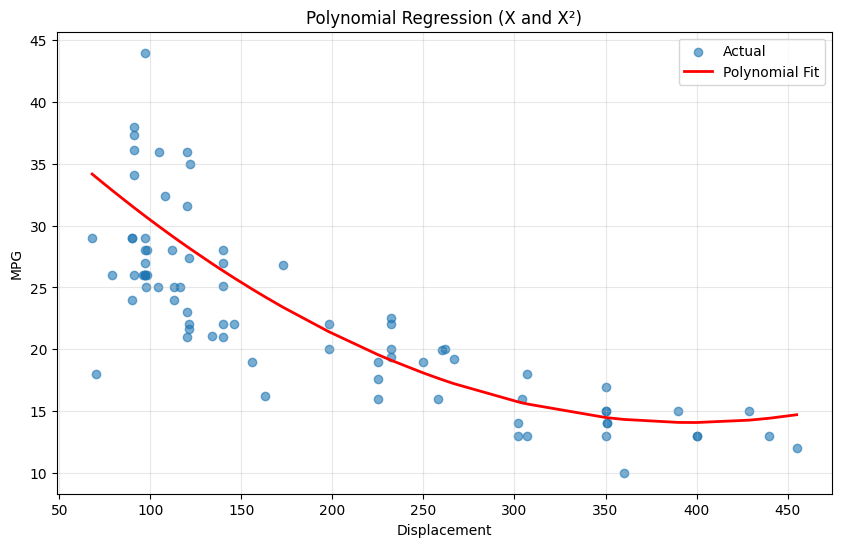

In [70]:
# Sort data for smooth curve plotting
sort_idx = np.argsort(X_test.values.flatten())
X_test_sorted = X_test.iloc[sort_idx]
X_poly_sorted = poly.transform(X_test_sorted)
y_pred_poly_sorted = poly_model.predict(X_poly_sorted)

plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, alpha=0.6, label='Actual')
plt.plot(X_test_sorted, y_pred_poly_sorted, 'r-', linewidth=2, label='Polynomial Fit')
plt.xlabel('Displacement')
plt.ylabel('MPG')
plt.title('Polynomial Regression (X and X²)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [73]:
n_poly = len(y_test)
p_poly = X_poly_test.shape[1]  # 3 features (1, X, X²)
r2_poly = r2_score(y_test, y_pred2)
r2_adj_poly = 1 - (1 - r2_poly) * (n_poly - 1) / (n_poly - p_poly - 1)

print(f"PLR R2: {r2_poly:.4f}")
print(f"PLR R2_adj: {r2_adj_poly:.4f}")

PLR R2: 0.5954
PLR R2_adj: 0.5793


Although the gap between the R2_adj of PLR and its actual R2 is small, it shows that it is worse than or around the same value as our SLR R2 (~0.58). 

This means that the Polynomial Features doesn't really adds to the improvement of our model. A simple straight-line model can also get the work done.

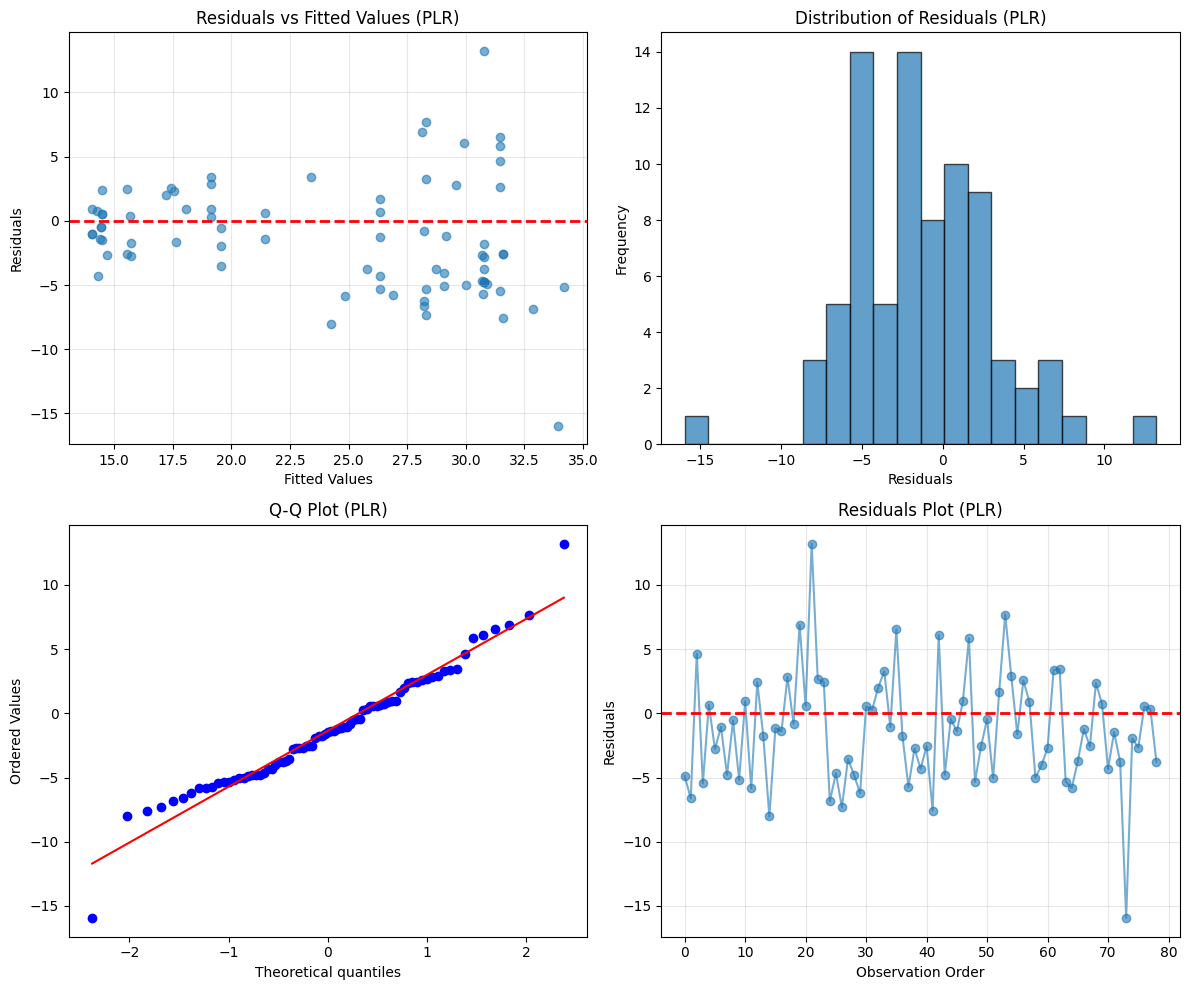

Mean of Residuals: -1.348268 (should be ~0)
Std Dev of Residuals: 4.3395
Min Residual: -15.9360
Max Residual: 13.2121


In [76]:
# Calculate residuals for Polynomial Regression
residuals_poly = y_test - y_pred2  # Test residuals

# Create diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Residuals vs Fitted Values (check homoscedasticity)
axes[0, 0].scatter(y_pred2, residuals_poly, alpha=0.6)
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted Values (PLR)')
axes[0, 0].grid(True, alpha=0.3)

# 2. Histogram of Residuals (check normality)
axes[0, 1].hist(residuals_poly, bins=20, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Residuals')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Residuals (PLR)')

# 3. Q-Q Plot (check normality)
from scipy import stats
stats.probplot(residuals_poly, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (PLR)')

# 4. Residuals over order (check independence)
axes[1, 1].plot(residuals_poly.values, 'o-', alpha=0.6)
axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Observation Order')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('Residuals Plot (PLR)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Mean of Residuals: {np.mean(residuals_poly):.6f} (should be ~0)")
print(f"Std Dev of Residuals: {np.std(residuals_poly):.4f}")
print(f"Min Residual: {np.min(residuals_poly):.4f}")
print(f"Max Residual: {np.max(residuals_poly):.4f}")

The residuals is noticably worse than our MLR.

In [75]:
df_perf

,R2,RMSE/MEAN,MAPE
SLR,0.584106,0.201740,0.170250
MLR,0.792277,0.142575,0.120395
PLR,0.595439,0.198972,0.158611


According the the performance of the three, MLR seems to be the clear winner here. It has significantly higher R2 compared to the other 2.

This suggests that most, if not all of the features all contribute significantly to our target `mpg`. 

## **II. Logistic Regression**

## **II. Logistic Regression**

[Cardiovascular diseases (CVDs)](https://www.who.int/health-topics/cardiovascular-diseases#tab=tab_1) are the leading cause of death globally, taking an estimated 17.9 million lives each year ([WHO](https://www.who.int/health-topics/cardiovascular-diseases#tab=tab_1)). CVDs are a group of disorders of the heart and blood vessels and include coronary heart disease, cerebrovascular disease, rheumatic heart disease and other conditions. More than four out of five CVD deaths are due to heart attacks and strokes, and one third of these deaths occur prematurely in people under 70 years of age. This research intends to pinpoint the most relevant/risk factors of heart disease as well as predict the overall risk using logistic regression.


We will explore [Kaggle Heart Disease Dataset](https://www.kaggle.com/datasets/dileep070/heart-disease-prediction-using-logistic-regression). Load the dataset into the environment.

In [77]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dileep070/heart-disease-prediction-using-logistic-regression")
import pandas as pd
data = pd.read_csv(path + "/framingham.csv")
data.head()

100%|██████████| 58.4k/58.4k [00:00<00:00, 351kB/s]

Extracting files...


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## **1. Data Preprocessing and EDA**

**A. Univariate Analysis**

- Check and modify if there is any column with wrong data type.
- Are there any missing values in this dataset? If so, compute percentage of missing values within each column containing such values and properly handle them.
- Compute descriptive statistics of the data and visualize their distribution.
- Pick a few columns and describe their distribution.

In [79]:
# Check and modify if there is any column with wrong data type
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


- education is better being category
- BPMeds is better being int (only 0 and 1)
- cigsPerDay can be int (discrete values)

In [91]:
# Check for missing values first before converting dtypes
data.isna().sum() * 100 / len(data)


male               0.000000
age                0.000000
education          2.477584
currentSmoker      0.000000
cigsPerDay         0.684285
BPMeds             1.250590
prevalentStroke    0.000000
prevalentHyp       0.000000
diabetes           0.000000
totChol            1.179802
sysBP              0.000000
diaBP              0.000000
BMI                0.448325
heartRate          0.023596
glucose            9.155262
TenYearCHD         0.000000
dtype: float64

In [92]:
# Let's study glucose more, but other than that, let's drop the other columns which has just little amount of missing values
data_cleaned = data.dropna(subset=data.columns.difference(['glucose']))

In [94]:
data_cleaned.isna().sum() * 100 / len(data)
# Since glucose now only has less than 10%, let's just drop it too.

male               0.000000
age                0.000000
education          0.000000
currentSmoker      0.000000
cigsPerDay         0.000000
BPMeds             0.000000
prevalentStroke    0.000000
prevalentHyp       0.000000
diabetes           0.000000
totChol            0.000000
sysBP              0.000000
diaBP              0.000000
BMI                0.000000
heartRate          0.000000
glucose            7.810288
TenYearCHD         0.000000
dtype: float64

In [97]:
data_cleaned = data_cleaned.dropna()

In [98]:
data_cleaned.shape[0]

3656

In [103]:
print(1 -len(data_cleaned) / len(data))
# We dropped ~14% of our total data

0.1373289287399717


In [113]:
data_cleaned['education'] = data_cleaned['education'].astype('category')
data_cleaned['BPMeds'] = data_cleaned['BPMeds'].astype('int64')
data_cleaned['cigsPerDay'] = data_cleaned['cigsPerDay'].astype('int64')

C:\Users\eungl\AppData\Local\Temp\ipykernel_22236\3279675549.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['education'] = data_cleaned['education'].astype('category')
C:\Users\eungl\AppData\Local\Temp\ipykernel_22236\3279675549.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['BPMeds'] = data_cleaned['BPMeds'].astype('int64')
C:\Users\eungl\AppData\Local\Temp\ipykernel_22236\3279675549.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a D

In [114]:
data_cleaned.dtypes

male                  int64
age                   int64
education          category
currentSmoker         int64
cigsPerDay            int64
BPMeds                int64
prevalentStroke       int64
prevalentHyp          int64
diabetes              int64
totChol             float64
sysBP               float64
diaBP               float64
BMI                 float64
heartRate           float64
glucose             float64
TenYearCHD            int64
dtype: object

In [115]:
data_cleaned.describe()

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000,3656.000000
mean,0.443654,49.557440,0.489059,9.022155,0.030361,0.005744,0.311543,0.027079,236.873085,132.368025,82.912062,25.784185,75.730580,81.856127,0.152352
std,0.496883,8.561133,0.499949,11.918869,0.171602,0.075581,0.463187,0.162335,44.096223,22.092444,11.974825,4.065913,11.982952,23.910128,0.359411
min,0.000000,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,113.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.080000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.380000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.250000,144.000000,90.000000,28.040000,82.000000,87.000000,0.000000
max,1.000000,70.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,600.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


Numeric Columns:
['male', 'age', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']


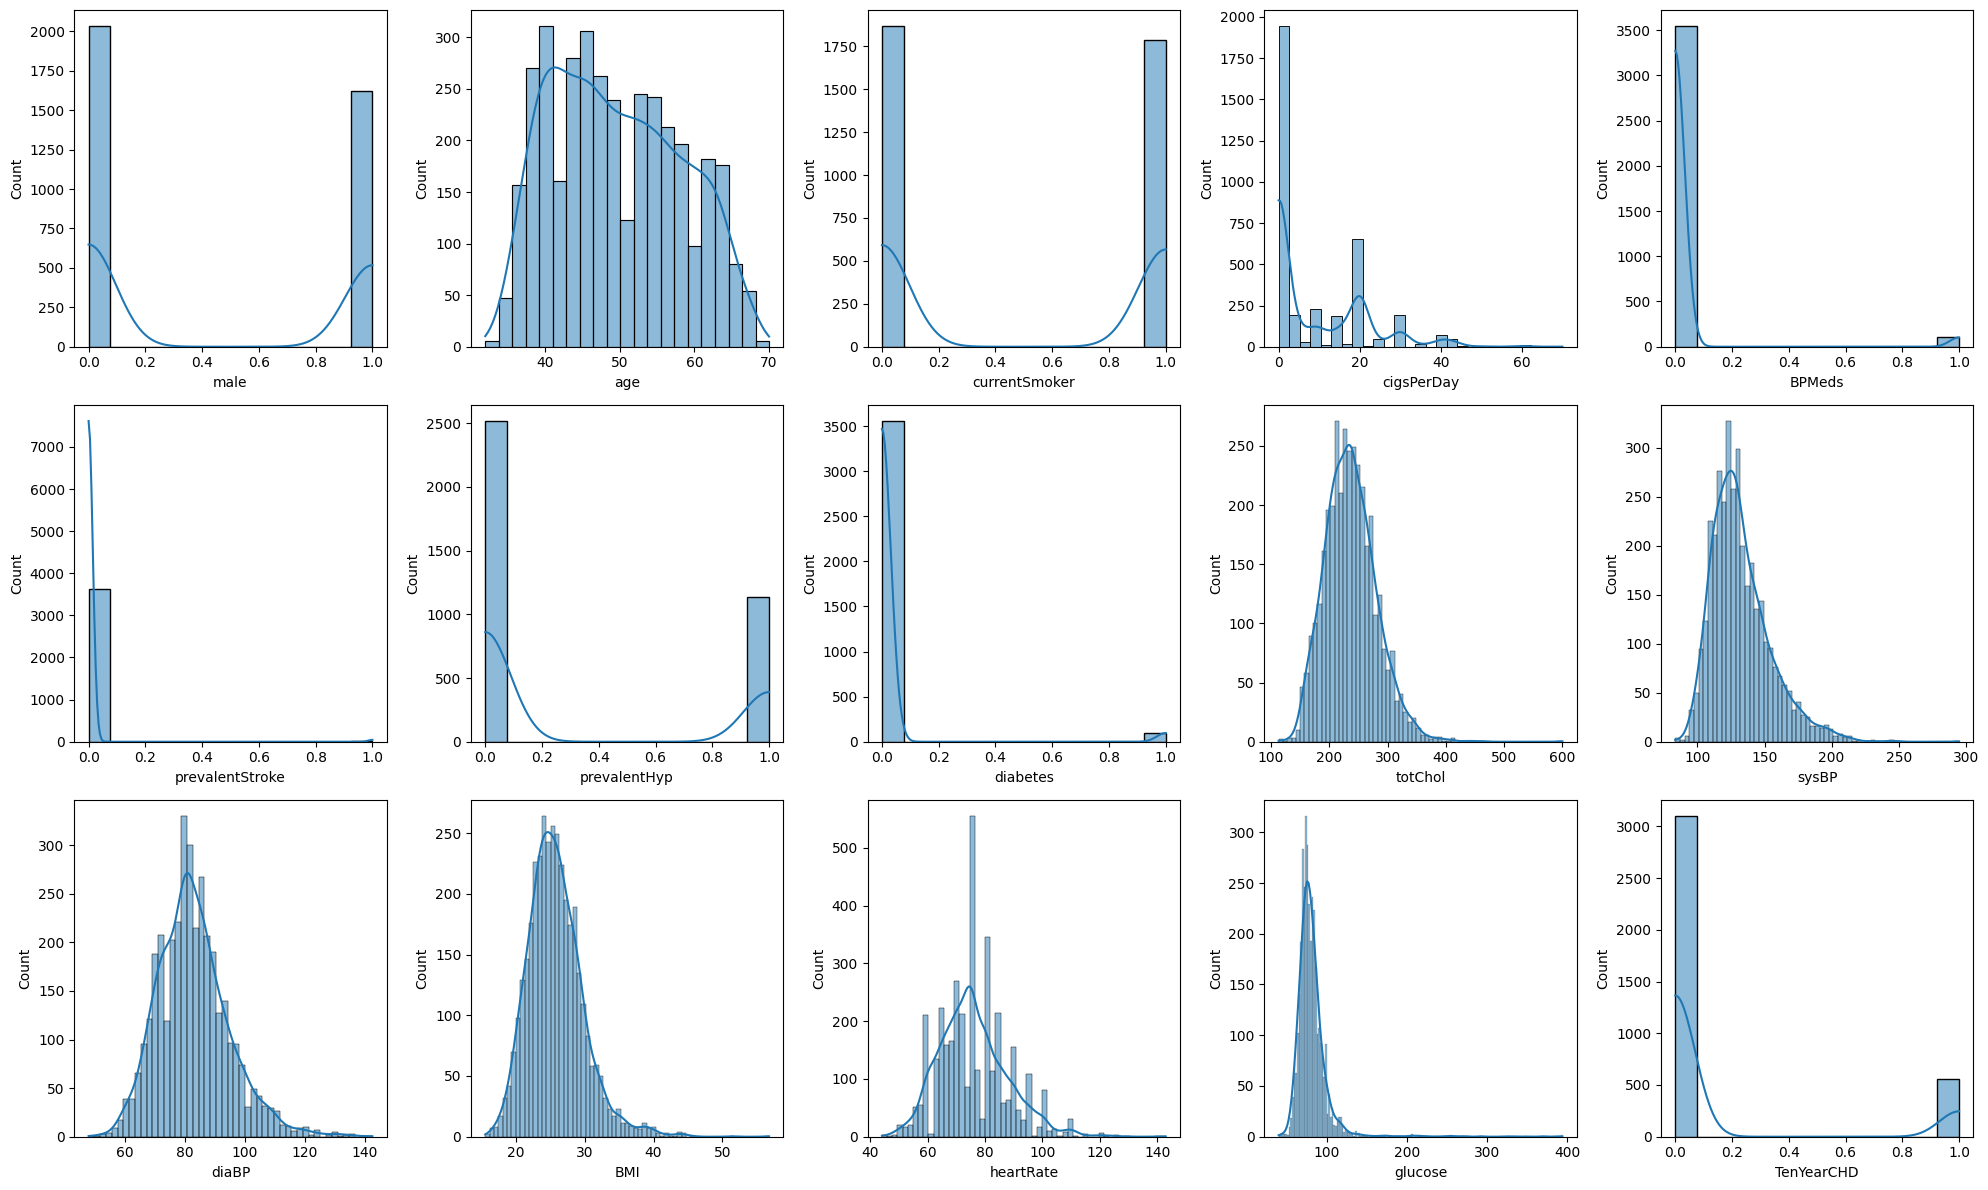

In [117]:
quant_cols = data_cleaned.select_dtypes(include='number').columns.tolist()

print("Numeric Columns:")
print(quant_cols)

fig, ax = plt.subplots(3, 5, figsize=(20, 12))

for i, var in enumerate(quant_cols):
    row = i // 5
    col = i % 5
    sns.histplot(data_cleaned, x=var, ax=ax[row, col], kde=True)

plt.tight_layout()
plt.show()

**B. Bivariate Analysis**

- Compute correlation matrix among numerical columns.
- Visualize relationship between each column to the target `TenYearCHD`.
- Draft a list of columns that you think is most related to the target.


Numeric Columns:
['male', 'age', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']


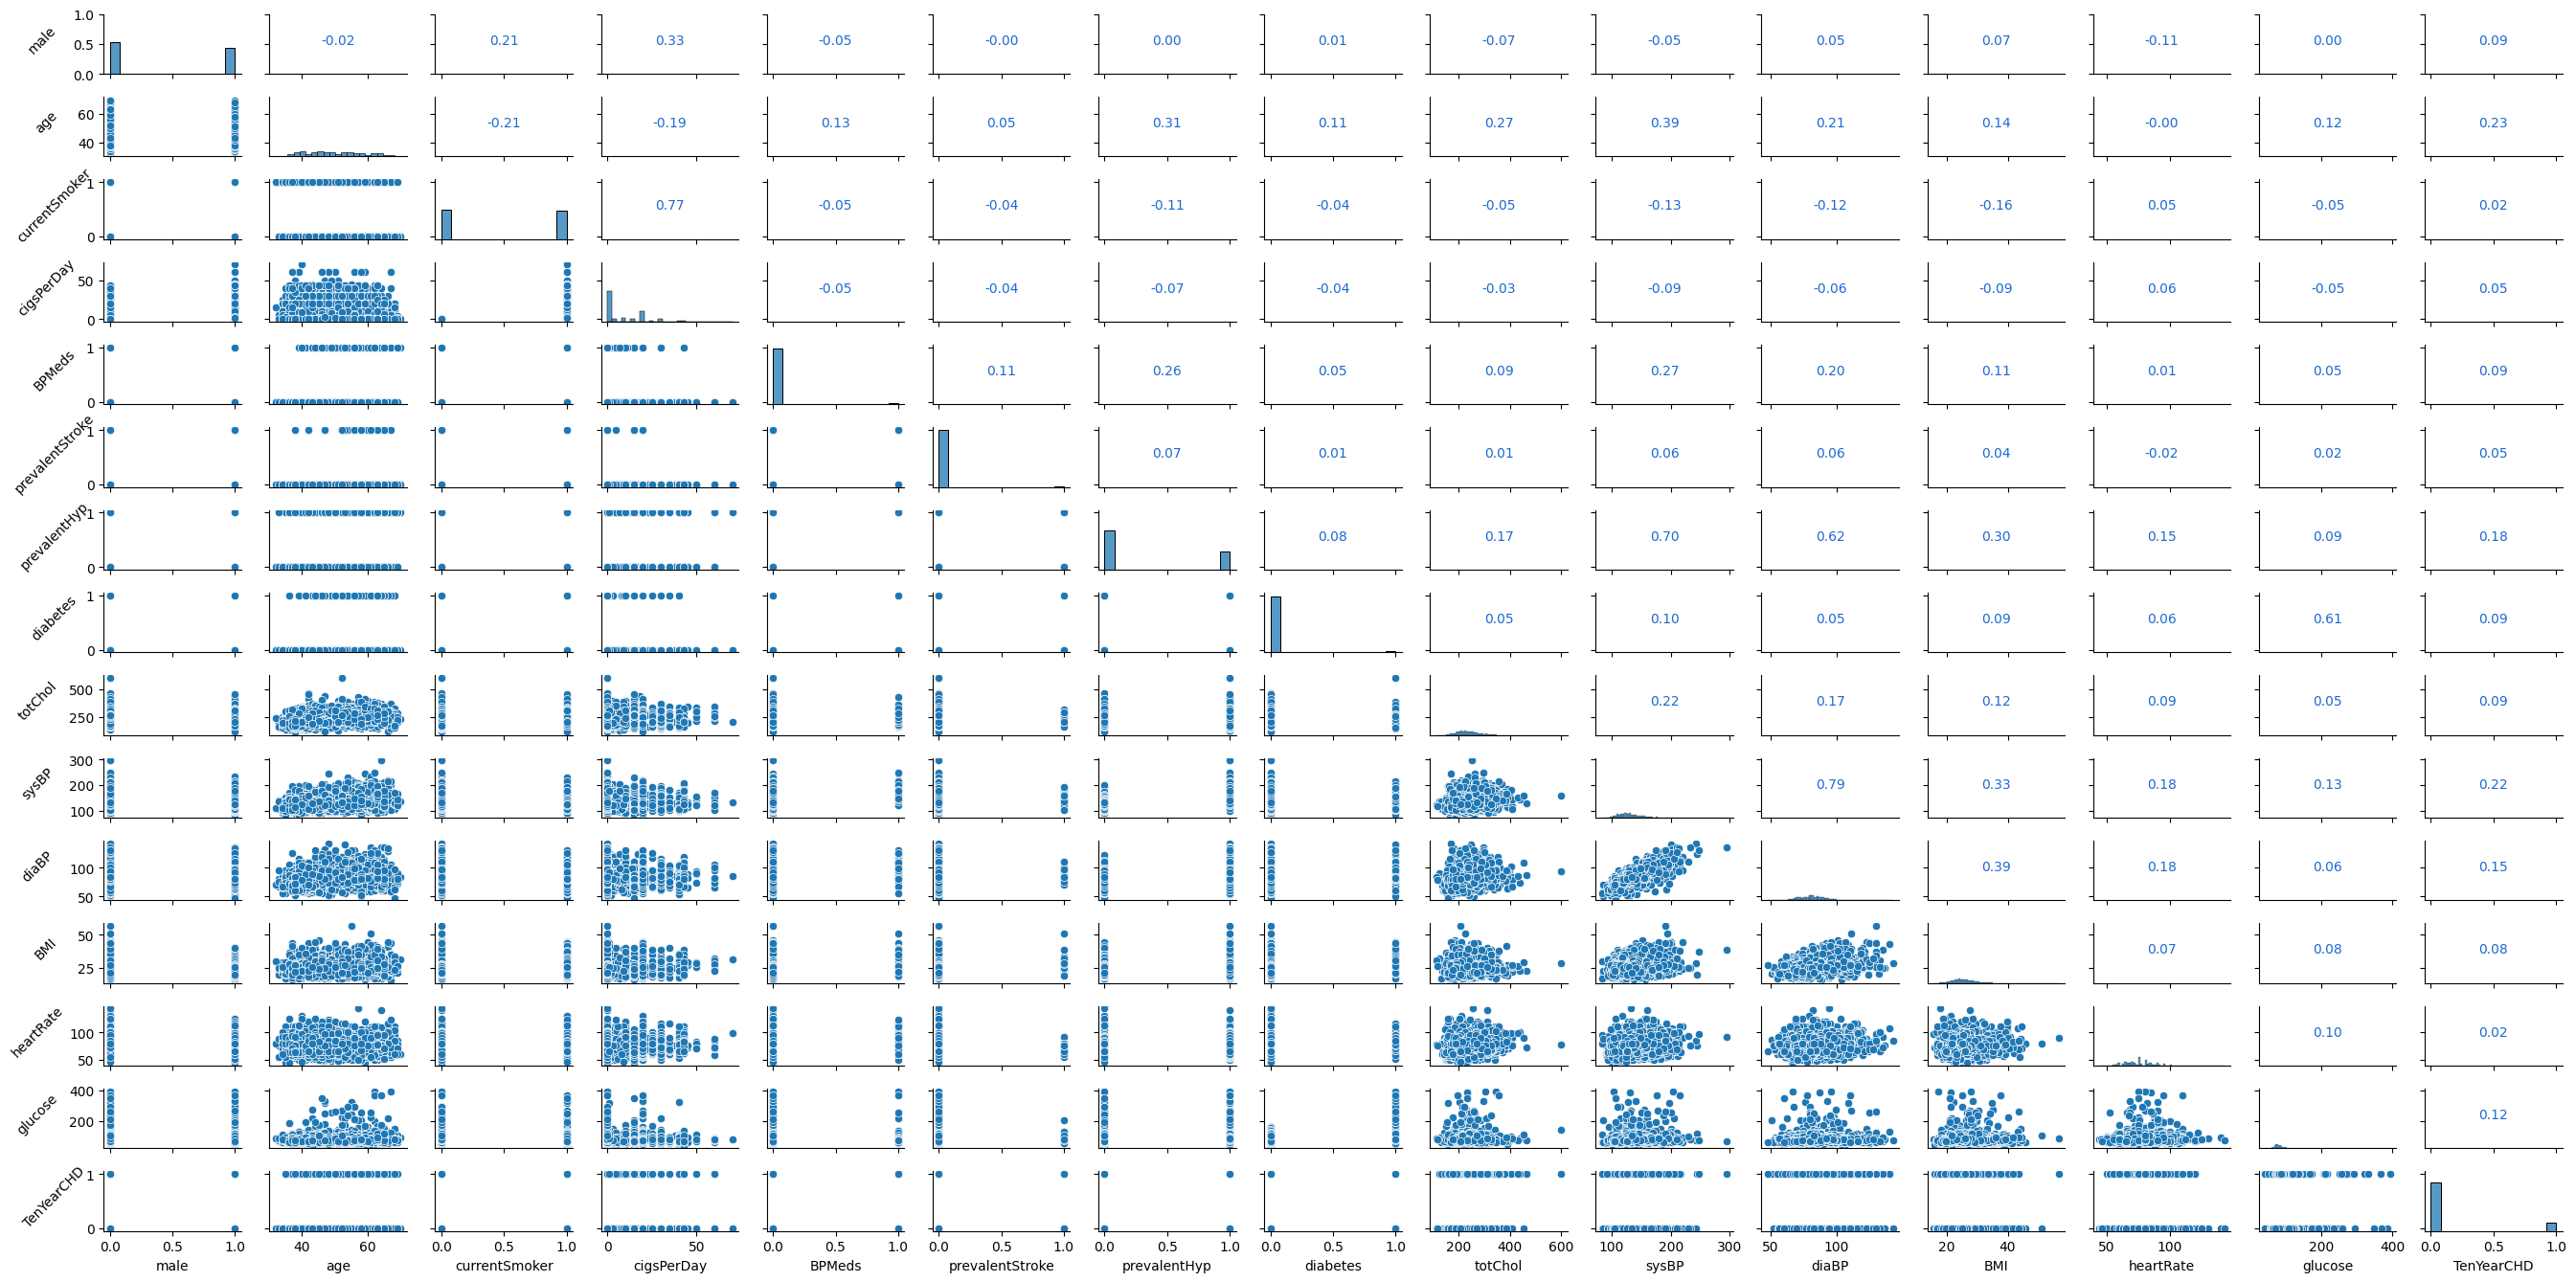

In [116]:
# Get numeric columns only
numeric_cols = data_cleaned.select_dtypes(include='number').columns.tolist()

print("\nNumeric Columns:")
print(numeric_cols)

# Create PairGrid like before
pair_grid = sns.PairGrid(data=data_cleaned[numeric_cols], height=0.9, aspect=2)

# Map plots to the lower triangle only
pair_grid.map_lower(sns.scatterplot)  # Scatterplots in the lower triangle
pair_grid.map_diag(sns.histplot)      # Histograms on the diagonal

# Add correlation values to upper triangle
def corr_func(x, y, **kws): 
    r1 = np.corrcoef(x, y)[0, 1]
    plt.gca().annotate(f"{r1:.2f}", xy=(0.5, 0.5), 
                       xycoords='axes fraction', 
                       ha='center', fontsize=10, color='#1d69d1')

pair_grid.map_upper(corr_func)

# Rotate y-axis labels for readability
for ax in pair_grid.axes[:, 0]:
    ax.set_ylabel(ax.get_ylabel(), rotation=45, labelpad=20)

plt.tight_layout()
plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\C'
<>:11: SyntaxWarning: invalid escape sequence '\C'
C:\Users\eungl\AppData\Local\Temp\ipykernel_22236\446607836.py:11: SyntaxWarning: invalid escape sequence '\C'
  print("\Correlations:")


Numeric Features (excluding target):
['male', 'age', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
\Correlations:
age                0.233810
sysBP              0.222885
prevalentHyp       0.181556
diaBP              0.150342
glucose            0.121942
diabetes           0.093397
male               0.091745
totChol            0.091127
BPMeds             0.089116
BMI                0.081931
cigsPerDay         0.052159
prevalentStroke    0.048351
heartRate          0.020523
currentSmoker      0.019176
Name: TenYearCHD, dtype: float64




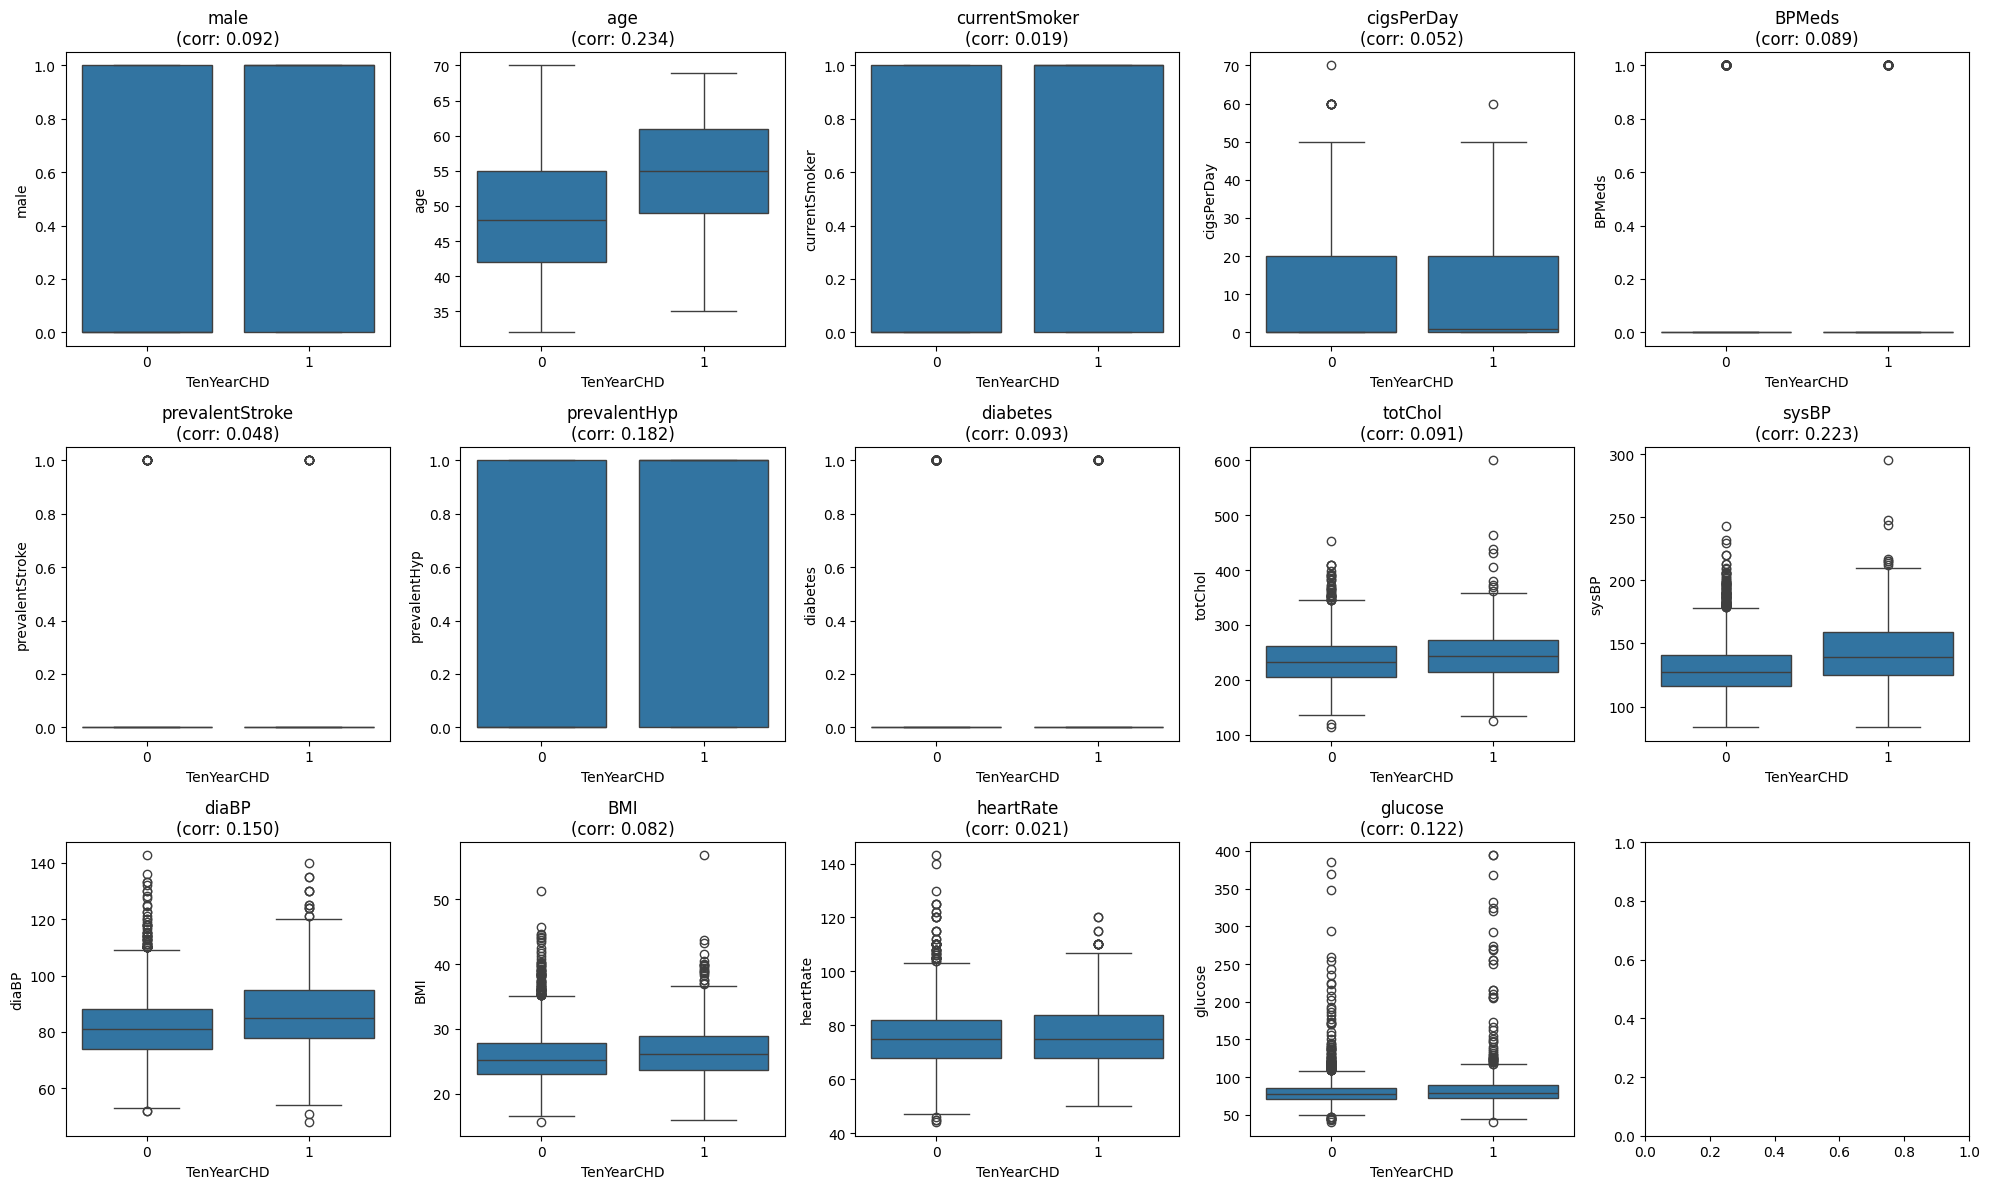

In [129]:
# Get numeric columns excluding target
numeric_cols = data_cleaned.select_dtypes(include='number').columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'TenYearCHD']  # Remove target from features

print("Numeric Features (excluding target):")
print(numeric_cols)

# Compute correlations with target
corr_with_target = data_cleaned[numeric_cols + ['TenYearCHD']].corr()['TenYearCHD'].drop('TenYearCHD')

print("\Correlations:")
print(corr_with_target.sort_values(ascending=False))
print("\n")

# Visualize relationship between each feature and target using box plots
fig, ax = plt.subplots(3, 5, figsize=(20, 12))

for i, var in enumerate(numeric_cols):
    row = i // 5
    col = i % 5
    sns.boxplot(data=data_cleaned, x='TenYearCHD', y=var, ax=ax[row, col])
    ax[row, col].set_title(f'{var}\n(corr: {corr_with_target[var]:.3f})')

plt.tight_layout()
plt.show()

## **2. Build logistic regression models**

**A. Simple Logistic Regression Model**

- Split the data into $80\%-20\%$ of training and testing data using `train_test_split` from `sklearn.preprocessing` module.
- Build a logistic regression model called `lg0` using only one selected input to predict the target `TenYearCHD`.
- Evaluate performance of the model built in the previous step using metrics such as `accuracy`, `precision`, `recall` and `f1_score` (from `sklearn.metrics` module).
- Write down explicit formula of your model.

**B. Multiple Logistic Regression Model**

- Build a logistic regression model (called `lg1`) to predict the target using just the columns drafted in part **1.B**.
- Measure its performance on the test data using all metrics.
- Build another logistic regression model using all the columns (called `lg2`).
- Compute its performance on the test data using all the metrics.
- Conclude.

In [ ]:
# To do

# Further readings
- [Linear Regression Module, sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
- [Linear Regression in Machine learning, geeks for geeks](https://www.geeksforgeeks.org/ml-linear-regression/).
- [Linear Regression, wiki](https://en.wikipedia.org/wiki/Linear_regression).
- [Logistic Regression, sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)
- [Logistic Regression, wiki](https://en.wikipedia.org/wiki/Logistic_regression)
- [Introduction to statistical learning, James et al. (2021)](https://www.statlearning.com/).